# **Preprocessing e pulizia dei dati**

Questo notebook guida il processo completo di pulizia e preprocessing del dataset. Le principali fasi includono:

- **Caricamento e analisi iniziale**: Importazione del dataset, ispezione della struttura, delle tipologie di dati e dei valori mancanti.
- **Gestione dei dati mancanti**: Identificazione delle colonne con troppi valori nulli e loro rimozione; imputazione dei valori mancanti su colonne numeriche e categoriche.
- **Pulizia e trasformazione dei dati**: Conversione di colonne testuali in valori numerici (es. misure con unità), parsing di liste, estrazione di informazioni da stringhe complesse (es. potenza, coppia, numero di posti e cilindri).
- **Normalizzazione dei valori booleani**: Conversione di colonne booleane da stringhe a veri valori booleani.
- **Gestione delle date**: Conversione delle date e creazione di nuove feature temporali.
- **Pulizia dei testi**: Rimozione di tag e caratteri speciali dalle descrizioni.
- **Rimozione dei duplicati**: Identificazione e rimozione di annunci duplicati tramite il VIN, mantenendo solo il più recente.
- **Controlli di consistenza**: Verifica e correzione di incoerenze tra colonne correlate (es. colori, dealer).
- **Esportazione finale**: Salvataggio del dataset pulito e pronto per analisi o modellazione.

## **Import delle librerie**

In [42]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import re
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
import seaborn as sns
sns.set_style("whitegrid")  # This sets the 'seab_
sns.set_palette('colorblind')
%matplotlib inline

# Pandas display options
pd.set_option('display.max_columns', None)  # Mostra tutte le colonne

## **1. Caricamento e analisi della struttura dei dati con Pandas**
Caricamento del CSV e analisi della struttura.

In [43]:
# Define the path to the dataset
file_path = '../data/used_cars_data.csv'  # Adjust this path as needed

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(file_path)

# Display basic information about the dataset
print(f"Dataset shape: {df.shape}")
print(f"\nMemory usage: {df.memory_usage().sum() / 1024**2:.2f} MB")

Dataset shape: (3000040, 66)

Memory usage: 1470.59 MB


In [44]:
# Display the first few rows of the dataset
df.head()

,vin,back_legroom,bed,bed_height,bed_length,body_type,cabin,city,city_fuel_economy,combine_fuel_economy,daysonmarket,dealer_zip,description,engine_cylinders,engine_displacement,engine_type,exterior_color,fleet,frame_damaged,franchise_dealer,franchise_make,front_legroom,fuel_tank_volume,fuel_type,has_accidents,height,highway_fuel_economy,horsepower,interior_color,isCab,is_certified,is_cpo,is_new,is_oemcpo,latitude,length,listed_date,listing_color,listing_id,longitude,main_picture_url,major_options,make_name,maximum_seating,mileage,model_name,owner_count,power,price,salvage,savings_amount,seller_rating,sp_id,sp_name,theft_title,torque,transmission,transmission_display,trimId,trim_name,vehicle_damage_category,wheel_system,wheel_system_display,wheelbase,width,year
0,ZACNJABB5KPJ92081,35.1 in,NaN,NaN,NaN,SUV / Crossover,NaN,Bayamon,NaN,NaN,522,960,[!@@Additional Info@@!]Engine: 2.4L I4 ZERO EV...,I4,1300.0,I4,Solar Yellow,NaN,NaN,True,Jeep,41.2 in,12.7 gal,Gasoline,NaN,66.5 in,NaN,177.0,Black,NaN,NaN,NaN,True,NaN,18.3988,166.6 in,2019-04-06,YELLOW,237132766,-66.1582,https://static.cargurus.com/images/forsale/202...,['Quick Order Package'],Jeep,5 seats,7.0,Renegade,NaN,"177 hp @ 5,750 RPM",23141.0,NaN,0,2.8,370599.0,Flagship Chrysler,NaN,"200 lb-ft @ 1,750 RPM",A,9-Speed Automatic Overdrive,t83804,Latitude FWD,NaN,FWD,Front-Wheel Drive,101.2 in,79.6 in,2019
1,SALCJ2FX1LH858117,38.1 in,NaN,NaN,NaN,SUV / Crossover,NaN,San Juan,NaN,NaN,207,922,"[!@@Additional Info@@!]Keyless Entry,Ebony Mor...",I4,2000.0,I4,Narvik Black,NaN,NaN,True,Land Rover,39.1 in,17.7 gal,Gasoline,NaN,68 in,NaN,246.0,Black (Ebony),NaN,NaN,NaN,True,NaN,18.4439,181 in,2020-02-15,BLACK,265946296,-66.0785,https://static.cargurus.com/images/forsale/202...,['Adaptive Cruise Control'],Land Rover,7 seats,8.0,Discovery Sport,NaN,"246 hp @ 5,500 RPM",46500.0,NaN,0,3.0,389227.0,Land Rover San Juan,NaN,"269 lb-ft @ 1,400 RPM",A,9-Speed Automatic Overdrive,t86759,S AWD,NaN,AWD,All-Wheel Drive,107.9 in,85.6 in,2020
2,JF1VA2M67G9829723,35.4 in,NaN,NaN,NaN,Sedan,NaN,Guaynabo,17.0,NaN,1233,969,NaN,H4,2500.0,H4,None,False,False,True,FIAT,43.3 in,15.9 gal,Gasoline,False,58.1 in,23.0,305.0,None,False,NaN,NaN,False,NaN,18.3467,180.9 in,2017-04-25,UNKNOWN,173473508,-66.1098,NaN,"['Alloy Wheels', 'Bluetooth', 'Backup Camera',...",Subaru,5 seats,NaN,WRX STI,3.0,"305 hp @ 6,000 RPM",46995.0,False,0,NaN,370467.0,FIAT de San Juan,False,"290 lb-ft @ 4,000 RPM",M,6-Speed Manual,t58994,Base,NaN,AWD,All-Wheel Drive,104.3 in,78.9 in,2016
3,SALRR2RV0L2433391,37.6 in,NaN,NaN,NaN,SUV / Crossover,NaN,San Juan,NaN,NaN,196,922,"[!@@Additional Info@@!]Fog Lights,7 Seat Packa...",V6,3000.0,V6,Eiger Gray,NaN,NaN,True,Land Rover,39 in,23.5 gal,Gasoline,NaN,73 in,NaN,340.0,Gray (Ebony/Ebony/Ebony),NaN,NaN,NaN,True,NaN,18.4439,195.1 in,2020-02-26,GRAY,266911050,-66.0785,https://static.cargurus.com/images/forsale/202...,NaN,Land Rover,7 seats,11.0,Discovery,NaN,"340 hp @ 6,500 RPM",67430.0,NaN,0,3.0,389227.0,Land Rover San Juan,NaN,"332 lb-ft @ 3,500 RPM",A,8-Speed Automatic Overdrive,t86074,V6 HSE AWD,NaN,AWD,All-Wheel Drive,115 in,87.4 in,2020
4,SALCJ2FXXLH862327,38.1 in,NaN,NaN,NaN,SUV / Crossover,NaN,San Juan,NaN,NaN,137,922,"[!@@Additional Info@@!]Keyless Entry,Ebony Mor...",I4,2000.0,I4,Narvik Black,NaN,NaN,True,Land Rover,39.1 in,17.7 gal,Gasoline,NaN,68 in,NaN,246.0,Black (Ebony),NaN,NaN,NaN,True,NaN,18.4439,181 in,2020-04-25,BLACK,270957414,-66.0785,https://static.cargurus.com/images/forsale/202...,['Adaptive Cruise Control'],Land Rover,7 seats,7.0,Discovery Sport,NaN,"246 hp @ 5,500 RPM",48880.0,NaN,0,3.0,389227.0,Land Rover San Juan,NaN,"269 lb-ft @ 1,400 RPM",A,9-Speed Automatic Overdrive,t86759,S AWD,NaN,AWD,All-Wheel Drive,107.9 in,85.6 in,2020


In [45]:
# Display information about columns and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000040 entries, 0 to 3000039
Data columns (total 66 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   vin                      object 
 1   back_legroom             object 
 2   bed                      object 
 3   bed_height               object 
 4   bed_length               object 
 5   body_type                object 
 6   cabin                    object 
 7   city                     object 
 8   city_fuel_economy        float64
 9   combine_fuel_economy     float64
 10  daysonmarket             int64  
 11  dealer_zip               object 
 12  description              object 
 13  engine_cylinders         object 
 14  engine_displacement      float64
 15  engine_type              object 
 16  exterior_color           object 
 17  fleet                    object 
 18  frame_damaged            object 
 19  franchise_dealer         bool   
 20  franchise_make           object 
 21  front_le

In [46]:
# Display statistical summary of the dataset
df.describe(include='all')

,vin,back_legroom,bed,bed_height,bed_length,body_type,cabin,city,city_fuel_economy,combine_fuel_economy,daysonmarket,dealer_zip,description,engine_cylinders,engine_displacement,engine_type,exterior_color,fleet,frame_damaged,franchise_dealer,franchise_make,front_legroom,fuel_tank_volume,fuel_type,has_accidents,height,highway_fuel_economy,horsepower,interior_color,isCab,is_certified,is_cpo,is_new,is_oemcpo,latitude,length,listed_date,listing_color,listing_id,longitude,main_picture_url,major_options,make_name,maximum_seating,mileage,model_name,owner_count,power,price,salvage,savings_amount,seller_rating,sp_id,sp_name,theft_title,torque,transmission,transmission_display,trimId,trim_name,vehicle_damage_category,wheel_system,wheel_system_display,wheelbase,width,year
count,3000040,2840771,19568,429098,429098,2986497,63533,3000040,2.508755e+06,0.0,3.000040e+06,3000040.0,2922139,2899459,2.827654e+06,2899459,3000014,1573445,1573445,3000040,2427405,2840771,2840771,2917316,1573445,2840771,2.508755e+06,2.827654e+06,2999875,1573445,0.0,182898,3000040,135362,3.000040e+06,2840771,3000040,3000040,3.000040e+06,3.000040e+06,2630947,2799992,3000040,2840771,2.855653e+06,3000040,1.483027e+06,2518614,3.000040e+06,1573445,3.000040e+06,2.959168e+06,2.999944e+06,3000040,1573445,2482247,2935855,2935855,2884213,2883746,0.0,2853308,2853308,2840771,2840771,3.000040e+06
unique,3000000,219,3,1,83,9,4,4687,NaN,NaN,NaN,9215.0,2519325,39,NaN,39,28665,2,2,2,48,101,182,8,2,472,NaN,NaN,45726,2,NaN,1,2,1,NaN,836,1749,15,NaN,NaN,2415855,279972,100,12,NaN,1429,NaN,2037,NaN,2,NaN,NaN,NaN,26148,2,2060,4,44,41329,9062,NaN,5,5,483,285,NaN
top,1FTFW1E43LKE95510,38.3 in,Short,--,67.1 in,SUV / Crossover,Crew Cab,Houston,NaN,NaN,NaN,77477.0,"[!@@Additional Info@@!]Front Wheel Drive,Power...",I4,NaN,I4,Black,False,False,True,Ford,40.9 in,26 gal,Gasoline,False,66.1 in,NaN,NaN,Black,False,NaN,True,False,True,NaN,231.9 in,2020-09-03,WHITE,NaN,NaN,https://static.cargurus.com/images/forsale/202...,"['Alloy Wheels', 'Bluetooth', 'Backup Camera']",Ford,5 seats,NaN,F-150,NaN,"355 hp @ 5,600 RPM",NaN,False,NaN,NaN,NaN,Carvana,False,"383 lb-ft @ 4,100 RPM",A,Automatic,t87739,SE FWD,NaN,FWD,Front-Wheel Drive,106.3 in,72.4 in,NaN
freq,2,113891,11822,429098,83655,1416402,51083,43777,NaN,NaN,NaN,7318.0,1064,1418291,NaN,1418291,162463,1238507,1558494,2431070,395521,229552,202824,2598436,1330491,85164,NaN,NaN,871393,1286504,NaN,182898,1529003,135362,NaN,97716,77385,666564,NaN,NaN,913,89079,476336,1875357,NaN,128586,NaN,88300,NaN,1562918,NaN,NaN,NaN,6993,1568179,88300,2418345,1255101,24785,87620,NaN,1261367,1261367,193512,131491,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.269325e+01,NaN,7.605973e+01,NaN,NaN,NaN,2.968488e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.947337e+01,2.479957e+02,NaN,NaN,NaN,NaN,NaN,NaN,3.698414e+01,NaN,NaN,NaN,2.754987e+08,-9.064224e+01,NaN,NaN,NaN,NaN,3.114690e+04,NaN,1.532644e+00,NaN,2.993337e+04,NaN,5.509768e+02,4.270413e+00,2.335224e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.017728e+03
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.807024e+00,NaN,1.088839e+02,NaN,NaN,NaN,1.348905e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.769252e+00,9.046639e+01,NaN,NaN,NaN,NaN,NaN,NaN,4.996819e+00,NaN,NaN,NaN,8.894123e+06,1.390589e+01,NaN,NaN,NaN,NaN,7.458675e+04,NaN,9.202928e-01,NaN,1.956617e+04,NaN,1.079448e+03,5.133017e-01,1.323221e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.178701e+00
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.000000e+00,NaN,0.000000e+00,NaN,NaN,NaN,7.000000e+02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+01,5.500000e+01,NaN,NaN,NaN,NaN,NaN,NaN,1.834670e+01,NaN,NaN,NaN,1.994620e+07,-1.579280e+02,NaN,NaN,NaN,NaN,0.000000e+00,NaN,1.000000e+00,NaN,1.650000e+02,NaN,0.000000e+00,1.000000e+00,4.159300e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.915000e+03
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.800000e+01,NaN,1.400000e+01,NaN,NaN,NaN,2.000000e+03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.500000e+01,1.750000e+02,NaN,NaN,NaN,N

In [47]:
# Check the number of unique values for each column
unique_counts = df.nunique().sort_values(ascending=False)
print(f"Number of unique values per column:\n{unique_counts}")

Number of unique values per column:
vin                        3000000
listing_id                 3000000
description                2519325
main_picture_url           2415855
major_options               279972
                            ...   
is_cpo                           1
is_oemcpo                        1
combine_fuel_economy             0
vehicle_damage_category          0
is_certified                     0
Length: 66, dtype: int64


## **2. Gestione dei dati mancanti**

In [48]:
# Calculate the percentage of missing values for each column
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Create a DataFrame to display missing values information
missing_info = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': missing_percentage
}).sort_values('Percentage (%)', ascending=False)

# Filter to display only columns with missing values
missing_columns = missing_info[missing_info['Missing Values'] > 0]
missing_columns

,Missing Values,Percentage (%)
vehicle_damage_category,3000040,100.000000
combine_fuel_economy,3000040,100.000000
is_certified,3000040,100.000000
bed,2980472,99.347742
cabin,2936507,97.882262
is_oemcpo,2864678,95.487993
is_cpo,2817142,93.903481
bed_height,2570942,85.696924
bed_length,2570942,85.696924
owner_count,1517013,50.566426


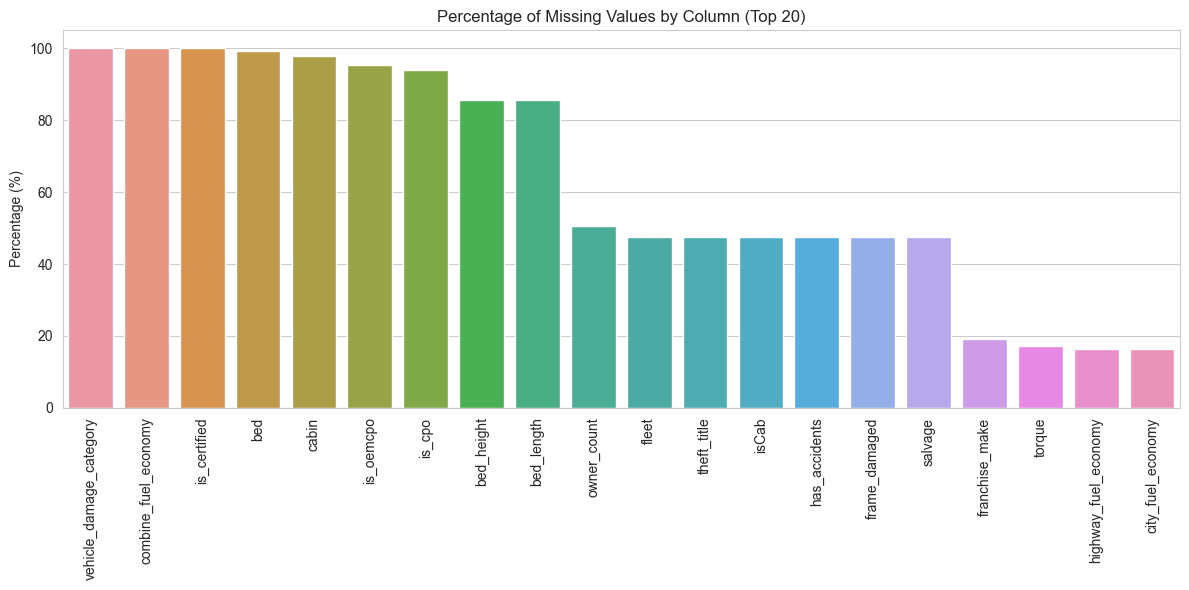

In [49]:
# Visualize columns with missing values (top 20)
plt.figure(figsize=(12, 6))
missing_cols = missing_columns.head(20)
sns.barplot(x=missing_cols.index, y='Percentage (%)', data=missing_cols)
plt.xticks(rotation=90)
plt.title('Percentage of Missing Values by Column (Top 20)')
plt.tight_layout()
plt.show()

In [50]:
# Check for empty strings or common placeholders in string columns
string_cols = df.select_dtypes(include=['object']).columns

# Dictionary to store columns with empty strings and their counts
empty_strings = {}
none_values = {}

for col in string_cols:
    # Count empty strings
    empty_count = (df[col] == '').sum()
    if empty_count > 0:
        empty_strings[col] = empty_count
    
    # Count 'None' or 'none' values
    none_count = ((df[col] == 'None') | (df[col] == 'none')).sum()
    if none_count > 0:
        none_values[col] = none_count

print("Columns with empty strings:")
for col, count in empty_strings.items():
    print(f"- {col}: {count} ({count/len(df)*100:.2f}%)")

print("\nColumns with 'None' values:")
for col, count in none_values.items():
    print(f"- {col}: {count} ({count/len(df)*100:.2f}%)")

Columns with empty strings:

Columns with 'None' values:
- exterior_color: 49929 (1.66%)
- interior_color: 383821 (12.79%)


## **3. Data Cleaning Functions**

Let's define functions to clean and transform the data.

In [51]:
# Function to clean numeric columns with units
def clean_numeric_with_units(series, unit_str):
    """Clean numeric columns with units (e.g., '10.5 in', '15 gal')."""
    if series.dtype == 'object':
        # First replace any '--' or other non-numeric placeholders with NaN
        cleaned = series.replace('--', np.nan)
        # Then remove the unit string and convert to float, handling errors
        try:
            return pd.to_numeric(
                cleaned.str.replace(unit_str, '').str.strip(), 
                errors='coerce'
            )
        except Exception as e:
            print(f"Error converting {series.name}: {e}")
            # Fallback method for troubleshooting
            problematic = cleaned.str.replace(unit_str, '').str.strip()
            print(f"Sample problematic values: {problematic[problematic.notna()].sample(min(5, len(problematic))).tolist()}")
            return pd.to_numeric(problematic, errors='coerce')
    return series

# Function to convert string boolean columns to actual boolean values
def convert_to_boolean(series):
    """Convert string 'True'/'False' to actual boolean values."""
    if series.dtype == 'object':
        # Replace empty strings with NaN first
        series = series.replace('', np.nan)
        # Convert to boolean (treating NaN as False)
        return series.map({'True': True, 'False': False}).fillna(False)
    return series

# Function to safely parse string lists
def parse_string_list(value):
    """Parse a string representation of a list into an actual list."""
    if pd.isna(value) or value == '':
        return []
    try:
        return ast.literal_eval(value)
    except (ValueError, SyntaxError):
        return []

# Function to extract numeric values from power and torque strings
def extract_power_value(power_str):
    """Extract horsepower value from power string (e.g., '177 hp @ 5,750 RPM')."""
    if pd.isna(power_str) or power_str == '':
        return np.nan
    match = re.search(r'(\d+)', str(power_str))
    if match:
        return float(match.group(1))
    return np.nan

def extract_rpm(rpm_str):
    """Extract RPM value from a string (e.g., '177 hp @ 5,750 RPM')."""
    if pd.isna(rpm_str) or rpm_str == '':
        return np.nan
    match = re.search(r'@\s*(\d[\d,]*)\s*RPM', str(rpm_str))
    if match:
        rpm_str = match.group(1).replace(',', '')
        return float(rpm_str)
    return np.nan

def extract_torque_value(torque_str):
    """Extract torque value from torque string (e.g., '200 lb-ft @ 1,750 RPM')."""
    if pd.isna(torque_str) or torque_str == '':
        return np.nan
    match = re.search(r'(\d+)', str(torque_str))
    if match:
        return float(match.group(1))
    return np.nan

# Function to extract seats from maximum_seating
def extract_seats(seating_str):
    """Extract number of seats from maximum_seating (e.g., '5 seats')."""
    if pd.isna(seating_str) or seating_str == '':
        return np.nan
    match = re.search(r'(\d+)', str(seating_str))
    if match:
        return int(match.group(1))
    return np.nan

# Function to extract engine cylinders as a number
def extract_cylinders(cylinder_str):
    """Extract number of cylinders from engine_cylinders (e.g., 'I4', 'V6')."""
    if pd.isna(cylinder_str) or cylinder_str == '':
        return np.nan
    match = re.search(r'(\d+)', str(cylinder_str))
    if match:
        return int(match.group(1))
    return np.nan

# Function to clean description field
def clean_description(desc):
    """Clean description field by removing special tags."""
    if pd.isna(desc) or desc == '':
        return ''
    # Remove special tags like [!@@Additional Info@@!]
    return re.sub(r'\[!@@.*?@@!\]', '', str(desc)).strip()

## **4. Data Processing e Cleaning**

In [52]:
# Create a copy of the original DataFrame to preserve the original data
df_clean = df.copy()

### **4.1 Rimozione colonne con valori mancanti a soglia (70%)**

In [53]:
# Identify and remove columns with a high percentage of missing values (> 70%)
high_missing_cols = missing_percentage[missing_percentage > 70].index.tolist()
print(f"Removing {len(high_missing_cols)} columns with >70% missing values:")
print(high_missing_cols)

df_clean = df_clean.drop(columns=high_missing_cols)

Removing 9 columns with >70% missing values:
['bed', 'bed_height', 'bed_length', 'cabin', 'combine_fuel_economy', 'is_certified', 'is_cpo', 'is_oemcpo', 'vehicle_damage_category']


### **4.2 Pulizia dei dati numerici con unità di misura**

In [54]:
# Clean numeric columns with units
columns_with_inches = ['back_legroom', 'front_legroom', 'height', 'length', 'wheelbase', 'width']
for col in columns_with_inches:
    if col in df_clean.columns:
        print(f"Cleaning column: {col}")
        df_clean[col] = clean_numeric_with_units(df_clean[col], ' in')

# Clean fuel_tank_volume (contains 'gal')
if 'fuel_tank_volume' in df_clean.columns:
    print(f"Cleaning column: fuel_tank_volume")
    df_clean['fuel_tank_volume'] = clean_numeric_with_units(df_clean['fuel_tank_volume'], ' gal')

# Check the result of conversion
print("\nSample values after cleaning:")
for col in columns_with_inches + ['fuel_tank_volume']:
    if col in df_clean.columns:
        print(f"{col}: {df_clean[col].sample(3).tolist()}")

Cleaning column: back_legroom
Cleaning column: front_legroom
Cleaning column: height
Cleaning column: length
Cleaning column: wheelbase
Cleaning column: width
Cleaning column: fuel_tank_volume

Sample values after cleaning:
back_legroom: [39.9, 43.6, 40.3]
front_legroom: [41.3, 42.2, 42.2]
height: [56.7, 56.9, 55.9]
length: [nan, 185.1, 192.4]
wheelbase: [114.0, 106.5, 120.9]
width: [71.4, 83.7, 73.0]
fuel_tank_volume: [12.4, 19.5, 16.2]


### **4.3 Conversione delle stringhe booleane in veri booleani**

In [55]:
# Convert string boolean columns to actual boolean values
boolean_columns = [
    'fleet', 'frame_damaged', 'franchise_dealer', 'has_accidents', 'isCab',
    'is_certified', 'is_cpo', 'is_new', 'is_oemcpo', 'salvage', 'theft_title'
]

for col in boolean_columns:
    if col in df_clean.columns:
        df_clean[col] = convert_to_boolean(df_clean[col])

### **4.4 Parsing delle liste di stringhe**

In [56]:
# Parse major_options from string representation to actual list
if 'major_options' in df_clean.columns:
    # Create a new column with parsed lists
    df_clean['major_options_list'] = df_clean['major_options'].apply(parse_string_list)
    
    # Create a feature for the number of options
    df_clean['num_major_options'] = df_clean['major_options_list'].apply(len)

### **4.5 Estrazione dei valori complessi**

In [57]:
# Extract horsepower and RPM from the power column
if 'power' in df_clean.columns:
    df_clean['horsepower_extracted'] = df_clean['power'].apply(extract_power_value)
    df_clean['horsepower_rpm'] = df_clean['power'].apply(extract_rpm)
    # Compare extracted horsepower with existing horsepower column if it exists
    if 'horsepower' in df_clean.columns:
        matching = np.isclose(df_clean['horsepower_extracted'], df_clean['horsepower'], equal_nan=True).mean() * 100
        print(f"Percentage of matching horsepower values: {matching:.2f}%")

# Fix error in extract_torque_value function (uses power_str instead of torque_str)
def extract_torque_value_fixed(torque_str):
    """Extract torque value from torque string (e.g., '200 lb-ft @ 1,750 RPM')."""
    if pd.isna(torque_str) or torque_str == '':
        return np.nan
    match = re.search(r'(\d+)', str(torque_str))
    if match:
        return float(match.group(1))
    return np.nan

# Extract torque value and RPM from the torque column
if 'torque' in df_clean.columns:
    df_clean['torque_value'] = df_clean['torque'].apply(extract_torque_value_fixed)
    df_clean['torque_rpm'] = df_clean['torque'].apply(extract_rpm)

# Extract number of seats from maximum_seating
if 'maximum_seating' in df_clean.columns:
    df_clean['seats'] = df_clean['maximum_seating'].apply(extract_seats)
    
# Extract number of cylinders from engine_cylinders
if 'engine_cylinders' in df_clean.columns:
    df_clean['cylinders'] = df_clean['engine_cylinders'].apply(extract_cylinders)
    # Show the mapping from engine_cylinders to extracted cylinders
    sample_cylinders = df_clean[['engine_cylinders', 'cylinders']].dropna().sample(min(10, len(df_clean)))
    print("\nSample cylinder extractions:")
    print(sample_cylinders)

Percentage of matching horsepower values: 80.12%

Sample cylinder extractions:
        engine_cylinders  cylinders
1826210               V6        6.0
839101                V6        6.0
583172                V8        8.0
831092                I4        4.0
1565273               I4        4.0
2213600               V6        6.0
258612                I4        4.0
856807                I3        3.0
1947297               V6        6.0
582034                V8        8.0


### **4.6 Gestione delle date**

In [58]:
# Convert listed_date to datetime
if 'listed_date' in df_clean.columns:
    df_clean['listed_date'] = pd.to_datetime(df_clean['listed_date'], errors='coerce')
    
    # Extract useful features from the date
    df_clean['listed_year'] = df_clean['listed_date'].dt.year
    df_clean['listed_month'] = df_clean['listed_date'].dt.month
    df_clean['listed_day'] = df_clean['listed_date'].dt.day
    df_clean['listed_dayofweek'] = df_clean['listed_date'].dt.dayofweek

### **4.7 Pulizia dei campi testuali**

In [59]:
# Clean description field
if 'description' in df_clean.columns:
    df_clean['description_cleaned'] = df_clean['description'].apply(clean_description)

## **5. Riempimento dei dati mancanti rimasti**

In [60]:
# Check remaining missing values
remaining_missing = (df_clean.isnull().sum() / len(df_clean)) * 100
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)

print("Remaining columns with missing values:")
print(remaining_missing)

Remaining columns with missing values:
owner_count             50.566426
franchise_make          19.087579
torque_rpm              17.259570
torque                  17.259537
torque_value            17.259537
city_fuel_economy       16.375948
highway_fuel_economy    16.375948
horsepower_rpm          16.047353
power                   16.047319
horsepower_extracted    16.047319
main_picture_url        12.302936
back_legroom             8.090792
major_options            6.668178
front_legroom            5.848489
horsepower               5.746123
engine_displacement      5.746123
fuel_tank_volume         5.355829
seats                    5.325596
width                    5.324929
height                   5.324496
length                   5.324129
wheelbase                5.323329
maximum_seating          5.308896
wheel_system_display     4.891001
wheel_system             4.891001
mileage                  4.812836
trim_name                3.876415
trimId                   3.860849
engine_ty

In [61]:
# Impute missing numerical values
numerical_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns

# Choose appropriate imputation strategy for each numerical column
for col in numerical_cols:
    # Skip columns that shouldn't be imputed (e.g., target variables like price)
    if col == 'price':
        continue
        
                
    # If missing values in this column
    if df_clean[col].isnull().sum() > 0:
        # Use median for most columns to be robust against outliers
        median_value = df_clean[col].median()
        
        # Create an indicator feature before imputation
        df_clean[f'{col}_missing'] = df_clean[col].isnull().astype(int)
        
        # Impute with median
        df_clean[col] = df_clean[col].fillna(median_value)
        
        print(f"Imputed {col} with median value: {median_value}")

Imputed back_legroom with median value: 38.2
Imputed city_fuel_economy with median value: 21.0
Imputed engine_displacement with median value: 2500.0
Imputed front_legroom with median value: 42.0
Imputed fuel_tank_volume with median value: 17.7
Imputed height with median value: 66.1
Imputed highway_fuel_economy with median value: 29.0
Imputed horsepower with median value: 244.0
Imputed length with median value: 189.9
Imputed mileage with median value: 8267.0
Imputed owner_count with median value: 1.0
Imputed seller_rating with median value: 4.341463414634147
Imputed sp_id with median value: 281627.0
Imputed wheelbase with median value: 111.2
Imputed width with median value: 77.3
Imputed horsepower_extracted with median value: 250.0
Imputed horsepower_rpm with median value: 6000.0
Imputed torque_value with median value: 258.0
Imputed torque_rpm with median value: 4000.0
Imputed seats with median value: 5.0
Imputed cylinders with median value: 4.0


In [62]:
# Impute missing categorical values
categorical_cols = df_clean.select_dtypes(include=['object']).columns

for col in categorical_cols:
    # If missing values in this column
    if df_clean[col].isnull().sum() > 0 or (df_clean[col] == '').sum() > 0:
        # Replace empty strings with NaN first
        df_clean[col] = df_clean[col].replace('', np.nan)
        
        # Create an indicator feature
        df_clean[f'{col}_missing'] = df_clean[col].isnull().astype(int)
        
        # For color fields, use 'Unknown' as replacement
        if 'color' in col:
            df_clean[col] = df_clean[col].fillna('Unknown')
        else:
            # For other categoricals, use most common value (mode)
            mode_value = df_clean[col].mode()[0]
            df_clean[col] = df_clean[col].fillna(mode_value)
            
        print(f"Imputed {col} with value: {df_clean[col].mode()[0]}")

Imputed body_type with value: SUV / Crossover
Imputed description with value: [!@@Additional Info@@!]Front Wheel Drive,Power Steering,ABS,4-Wheel Disc Brakes,Brake Assist,Wheel Covers,Steel Wheels,Tires - Front Performance,Tires - Rear Performance,Temporary Spare Tire,Power Mirror(s),Rear Defrost,Intermittent Wipers,Daytime Running Lights,Automatic Headlights,AM/FM Stereo,MP3 Player,Steering Wheel Audio Controls,Bluetooth Connection,Auxiliary Audio Input,Bucket Seats,Rear Bench Seat,Adjustable Steering Wheel,Trip Computer,Power Windows,Keyless Entry,Power Door Locks,Cruise Control,Adaptive Cruise Control,Climate Control,A/C,Cloth Seats,Driver Vanity Mirror,Passenger Vanity Mirror,Floor Mats,Power Windows,Power Door Locks,Trip Computer,Security System,Engine Immobilizer,Traction Control,Stability Control,Traction Control,Front Side Air Bag,Lane Departure Warning,Lane Keeping Assist,Lane Departure Warning,Tire Pressure Monitor,Driver Air Bag,Passenger Air Bag,Front Head Air Bag,Rear Head

## **6. Gestione ennuple (annunci) duplicati**

In [63]:
# Check for duplicates based on VIN
if 'vin' in df_clean.columns:
    vin_counts = df_clean['vin'].value_counts()
    duplicated_vins = vin_counts[vin_counts > 1].index
    
    print(f"Number of VINs appearing more than once: {len(duplicated_vins)}")
    print(f"Total duplicate rows based on VIN: {sum(vin_counts[vin_counts > 1]) - len(duplicated_vins)}")
    
    # If duplicates exist, keep the most recent listing for each VIN
    if len(duplicated_vins) > 0 and 'listed_date' in df_clean.columns:
        # Sort by listed_date (descending) and keep first occurrence of each VIN
        df_clean = df_clean.sort_values('listed_date', ascending=False)
        df_clean = df_clean.drop_duplicates(subset=['vin'], keep='first')
        print(f"After removing duplicates, dataset shape: {df_clean.shape}")

Number of VINs appearing more than once: 40
Total duplicate rows based on VIN: 40
After removing duplicates, dataset shape: (3000000, 111)


## **7. Controlli di consistenza tra colonne**

In [64]:
# Check consistency between franchise_dealer and franchise_make
if 'franchise_dealer' in df_clean.columns and 'franchise_make' in df_clean.columns:
    # Check if there are any records where franchise_dealer is True but franchise_make is empty
    inconsistent_franchise = df_clean[(df_clean['franchise_dealer'] == True) & 
                                      (df_clean['franchise_make'].isnull() | (df_clean['franchise_make'] == ''))]
    
    print(f"Found {len(inconsistent_franchise)} records where franchise_dealer is True but franchise_make is empty")
    
    # Fix inconsistencies by filling franchise_make with make_name where appropriate
    if len(inconsistent_franchise) > 0 and 'make_name' in df_clean.columns:
        # Where franchise_dealer is True but franchise_make is empty, use make_name
        mask = (df_clean['franchise_dealer'] == True) & (df_clean['franchise_make'].isnull() | (df_clean['franchise_make'] == ''))
        df_clean.loc[mask, 'franchise_make'] = df_clean.loc[mask, 'make_name']
        print(f"Fixed {mask.sum()} inconsistencies by copying values from make_name")

Found 0 records where franchise_dealer is True but franchise_make is empty


In [65]:
# Check consistency between exterior_color and listing_color
if 'exterior_color' in df_clean.columns and 'listing_color' in df_clean.columns:
    # Count records where one is filled but the other is empty
    ext_empty_list_filled = ((df_clean['exterior_color'].isnull() | (df_clean['exterior_color'] == '')) & 
                             df_clean['listing_color'].notna() & (df_clean['listing_color'] != ''))
    
    list_empty_ext_filled = ((df_clean['listing_color'].isnull() | (df_clean['listing_color'] == '')) & 
                             df_clean['exterior_color'].notna() & (df_clean['exterior_color'] != ''))
    
    print(f"Records with empty exterior_color but filled listing_color: {ext_empty_list_filled.sum()}")
    print(f"Records with empty listing_color but filled exterior_color: {list_empty_ext_filled.sum()}")
    
    # Choose listing_color as the standard (it seems more standardized based on your sample note)
    # Create a unified color column
    df_clean['unified_color'] = df_clean['listing_color']
    
    # Where listing_color is empty but exterior_color is not, use exterior_color
    mask = (df_clean['unified_color'].isnull() | (df_clean['unified_color'] == '')) & \
           df_clean['exterior_color'].notna() & (df_clean['exterior_color'] != '')
    
    df_clean.loc[mask, 'unified_color'] = df_clean.loc[mask, 'exterior_color']
    
    # Fill remaining empty values with 'Unknown'
    df_clean['unified_color'] = df_clean['unified_color'].fillna('Unknown')

Records with empty exterior_color but filled listing_color: 0
Records with empty listing_color but filled exterior_color: 0


## **8. Checks finali ed Export**

In [66]:
# Check final dataset for any remaining issues
print(f"Final dataset shape: {df_clean.shape}")
print(f"\nColumns in final dataset: {df_clean.columns.tolist()}")

# Check for any remaining missing values
remaining_missing = df_clean.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

if len(remaining_missing) > 0:
    print("\nRemaining missing values:")
    print(remaining_missing)
else:
    print("\nNo missing values remain in the dataset.")

Final dataset shape: (3000000, 112)

Columns in final dataset: ['vin', 'back_legroom', 'body_type', 'city', 'city_fuel_economy', 'daysonmarket', 'dealer_zip', 'description', 'engine_cylinders', 'engine_displacement', 'engine_type', 'exterior_color', 'fleet', 'frame_damaged', 'franchise_dealer', 'franchise_make', 'front_legroom', 'fuel_tank_volume', 'fuel_type', 'has_accidents', 'height', 'highway_fuel_economy', 'horsepower', 'interior_color', 'isCab', 'is_new', 'latitude', 'length', 'listed_date', 'listing_color', 'listing_id', 'longitude', 'main_picture_url', 'major_options', 'make_name', 'maximum_seating', 'mileage', 'model_name', 'owner_count', 'power', 'price', 'salvage', 'savings_amount', 'seller_rating', 'sp_id', 'sp_name', 'theft_title', 'torque', 'transmission', 'transmission_display', 'trimId', 'trim_name', 'wheel_system', 'wheel_system_display', 'wheelbase', 'width', 'year', 'major_options_list', 'num_major_options', 'horsepower_extracted', 'horsepower_rpm', 'torque_value', '

In [67]:
# Export the cleaned dataset
output_path = '../data/used_cars_cleaned.csv'
df_clean.to_csv(output_path, index=False)
print(f"Cleaned dataset exported to: {output_path}")

Cleaned dataset exported to: ../data/used_cars_cleaned.csv
